# Analysis of London Pedestrians and Bike Data

# Abstract

This report leverages various data science techniques to analyze pedestrian, cycle, and e-scooter volumes in Central London between May and July 2022, utilizing a dataset provided by Transportation for London. The objective is to extract meaningful insights for businesses and governmental organizations operating in the bike and e-scooter industries, offering valuable metrics for decision-making. The methods involve data scraping, cleaning, and processing using Python and relevant libraries. The results showcase trends and patterns in the data, providing actionable information for stakeholders.

# Keywords

London, transportation, data science, pedestrian, cycle, e-scooter, Central London, dataset, analysis, business, government, decision-making

# Introduction

## Background Information:
London, as a bustling metropolis, faces ongoing challenges in managing pedestrian and cyclist traffic. Understanding the dynamics of pedestrian, cycle, and e-scooter volumes is crucial for businesses and governmental organizations involved in the transportation sector. This analysis focuses on data collected in Central London, within the Congestion Charge zone, between May and July 2022.

## Objective:
The primary objective of this analysis is to extract meaningful insights from the provided dataset, aiding businesses and governmental organizations in decision-making related to bike and e-scooter services. By examining trends in pedestrian, cycle, and e-scooter volumes, the report aims to provide actionable information on the optimal timing and placement of hire stores, among other metrics.

## Scope:
The dataset spans three months, from May to July 2022, covering various parameters such as weather conditions, time of day, and direction of travel. The focus is on Central London, providing insights specific to this area

# Methods

Database fields include: 

- Year: Year when the counts took place/which the counts represents
- UnqID: Unique ID that identifies the count location
- Date: Date when the count took place.
- Weather: Description of the weather at the time and location of the count
- Time: Time when the count took place
- Day:  Indicates whether the count was done on a weekday or weekend. 
- Round: Character indicating the different iterations of the same site-year combination when multiple counts of the same site occur in the same wave of counts. Characters A to E represent weekdays while X and Y represent weekends (regardless of specific days)
- Dir: Direction of the count. This field is always one of Northbound, Southbound, Eastbound or Westbound
- Path: Path classification according to the definitions above
- Mode: Road user classification according to the definitions above
- Count: Total flow with the above parameters

## Data Description:
The dataset includes fields such as Year, Unique ID, Date, Weather, Time, Day, Round, Direction, Path, Mode, and Count. Noteworthy data points encompass the date and time of the count, weather conditions, and the mode of travel (e.g., cargo bikes, pedestrians). The dataset is sourced from Transportation for London.

## Methodology:
The analysis involves data scraping from a CSV file and subsequent cleaning to address missing values. Data processing includes converting the "Date" column to datetime format, extracting the month, and sorting the data by date and time. The dataset is then grouped by date, mode, month, weather, and path, and rows with zero counts are removed. Additional data processing involves converting the "Path" column to string, splitting it based on "-", and creating separate columns for place and bound. The final dataset is further grouped by bound and mode for detailed analysis.

## Tools Used:
The analysis utilizes Python, with key libraries such as pandas for data manipulation, matplotlib and seaborn for data visualization, and plotly express for interactive visualizations. These tools facilitate efficient data exploration, cleaning, and presentation of results.




# Scrape data from CSV file

First, the data was scraped from the CSV file using Pandas library. It was then putted into DataFrame which enables further inspection and prepares it for cleaning. 

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
# Using display instead of print for better formatted output and 
# therefore better user experience
# https://github.com/swcarpentry/python-novice-gapminder/issues/342
from IPython.display import display 
import plotly.express as px
import numpy as np
import seaborn as sns

# Scrape data from CSV file
csv = pd.read_csv("2022-Central.csv")
df = pd.DataFrame(csv)

# Inspecting the data

Next, data was inspected by looking into first five rows. That enabled clear inspection of rows, columns, and data entries. 

Then, data types for each column were inspected.

At the end, the basic Pandas analysis was perfomed. That didn't provide any meaningful data as the data is from only one year (2022) and the count at this point doesn't have context. 

In [93]:
# Prints the first 5 records
print(f"First five records from the TfL's database:")
display(df.head())

# Prints the data types of each column
print(f"\nData types of each column:")
display(df.dtypes)

# Prints the basic statistics

print(f"\nBasic statistics using Pandas 'describe' method:")
display(df.describe())

First five records from the TfL's database:


,Year,UnqID,Date,Weather,Time,Day,Round,Dir,Path,Mode,Count
0,2022,CENCY001,13/07/2022,Dry,06:00:00,Weekday,A,Northbound,Carriageway,Cargo bikes,0
1,2022,CENCY001,13/07/2022,Dry,06:15:00,Weekday,A,Northbound,Carriageway,Cargo bikes,0
2,2022,CENCY001,13/07/2022,Dry,06:30:00,Weekday,A,Northbound,Carriageway,Cargo bikes,0
3,2022,CENCY001,13/07/2022,Dry,06:45:00,Weekday,A,Northbound,Carriageway,Cargo bikes,0
4,2022,CENCY001,13/07/2022,Dry,07:00:00,Weekday,A,Northbound,Carriageway,Cargo bikes,0



Data types of each column:


Year        int64
UnqID      object
Date       object
Weather    object
Time       object
Day        object
Round      object
Dir        object
Path       object
Mode       object
Count       int64
dtype: object


Basic statistics using Pandas 'describe' method:


,Year,Count
count,370688.0,370688.000000
mean,2022.0,8.910607
std,0.0,34.284010
min,2022.0,0.000000
25%,2022.0,0.000000
50%,2022.0,0.000000
75%,2022.0,1.000000
max,2022.0,1709.000000


The initial inspection of the dataset revealed 370,688 records with various attributes, including year, date, weather, and count. Basic statistics highlighted the mean count to be 8.91, with a maximum count of 1,709. Data cleaning identified no missing values in the dataset.

# Clean Data

Data set was then inspected for any missing values and rows. It was noticed that no data is missing. 

In [94]:
# Identify missing values in the dataset
missing_data = df.isnull()

# Count the missing values in each column
missing_count = missing_data.sum()

print(f"The missing data:\n\n{missing_count}")

The missing data:

Year       0
UnqID      0
Date       0
Weather    0
Time       0
Day        0
Round      0
Dir        0
Path       0
Mode       0
Count      0
dtype: int64


# Data Processing

Next important step was data processing. 

Here the "Date" column was converted from object to datetime to then extract the month out of that column and generate a seperate column out of that data. 

Initially "Month" was a numerical value, so the dictionary was created to map each month number present in the data set (May, June, July) to the actual month name. 

Next, the "Dir" column was renamed for "Direction." This was done as the initial "Dir" didn't provide initial context for the user. This column indicated the direction in which the collected data point was moving. 

Then, the dataset was sorted by date and time in ascending order. 

After sorting the DataFrame by "Date" and "Time," the data was grouped by multiple columns, including "Date," "Mode," "Month," "Weather," and "Path." The purpose of this grouping was to aggregate the "Count" values for each unique combination of these columns.

This operation used the groupby method to group the data based on the specified columns and then applied the agg method to aggregate the "Count" values using the sum function.

Following this, rows where the "Count" had a value of 0 were dropped, resulting in a DataFrame named cleaned_data. The reset_index() method was used to reset the index of the DataFrame, making it more organized.

The next steps involved additional processing of the "Path" column. This was done to extract information about data in each of four bounds: Northbound, Southbound, Eastbound, and Westbound. Firstly, the "Path" column was converted to a string and split based on ("-"). This created a list of strings for each row in the "Path" column.

Afterward, the "Place" and "Bound" columns were accessed from the split "Path" column and assigned to new columns in the DataFrame.

Finally, the original "Path" column was dropped from the DataFrame as it was no longer needed.

The resulting DataFrame, cleaned_data, now includes the additional "Place" and "Bound" columns, providing more detailed information about the locations in the dataset. The data types of each column were printed, and the final cleaned DataFrame was displayed.

This data processing pipeline helps in preparing the data for further analysis, visualization, or modeling by ensuring that it is in a suitable format and contains relevant information.

In [95]:
# Convert the "Date" column to datetime (day/month/year)
# https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Gets the month column from the 'Date' column
df['Month'] = df['Date'].dt.month

# Create a dictionary to map company names to their headquarters' states
number_to_month = {
      5: "May",
      6: "June",
      7: "July",
}

# Replace numerical months with month names
df["Month"] = df["Month"].replace(number_to_month)

# Rename "Dir" column name with "Direction"
df = df.rename(columns={"Dir": "Direction"})

# Sort the DataFrame by 'Date' and 'Time'
df_sorted = df.sort_values(by=["Date", "Time"])

# Groups the data with the count of each mode type, each day, in each bound
df_grouped = df_sorted.groupby(["Date", "Mode", "Month", "Weather", "Path"]).agg({"Count": "sum"})

# Drop rows where 'Count' has a '0' value
cleaned_data = df_grouped[df_grouped["Count"] != 0].reset_index()

display(cleaned_data)

# Convert "Path" column to string and split based on "-"
cleaned_data['Path'] = cleaned_data['Path'].astype(str).str.split("-")

# Access the place and bound parts of the split "Path" column
cleaned_data = cleaned_data.assign(
    Place=cleaned_data['Path'].str[0],
    Bound=cleaned_data['Path'].str[1]
)

# Drop the original "Path" column
cleaned_data = cleaned_data.drop('Path', axis=1)

# Drop the original "Path" column if needed
# cleaned_data = cleaned_data.drop('Path', axis=1)

# Prints the data types of each column
print(f"\nData types after conversion:")
display(cleaned_data.dtypes)

# Display the DataFrame with the added "Place" and "Bound" columns
display(cleaned_data)

,Date,Mode,Month,Weather,Path,Count
0,2022-05-03,Cargo bikes,May,Dry,Carriageway,12
1,2022-05-03,Cargo bikes,May,Dry,Cycle lane - Eastbound,72
2,2022-05-03,Cargo bikes,May,Dry,Cycle lane - Westbound,23
3,2022-05-03,Cargo bikes,May,Dry,Pavement - Eastbound,13
4,2022-05-03,Cargo bikes,May,Dry,Pavement - Westbound,1
...,...,...,...,...,...,...
1005,2022-07-20,Pedestrians,July,Dry,Pavement - Eastbound,1871
1006,2022-07-20,Pedestrians,July,Dry,Pavement - Westbound,2426
1007,2022-07-20,Pedestrians,July,Wet,Carriageway,3
1008,2022-07-20,Pedestrians,July,Wet,Pavement - Eastbound,23



Data types after conversion:


Date       datetime64[ns]
Mode               object
Month              object
Weather            object
Count               int64
Place              object
Bound              object
dtype: object

,Date,Mode,Month,Weather,Count,Place,Bound
0,2022-05-03,Cargo bikes,May,Dry,12,Carriageway,NaN
1,2022-05-03,Cargo bikes,May,Dry,72,Cycle lane,Eastbound
2,2022-05-03,Cargo bikes,May,Dry,23,Cycle lane,Westbound
3,2022-05-03,Cargo bikes,May,Dry,13,Pavement,Eastbound
4,2022-05-03,Cargo bikes,May,Dry,1,Pavement,Westbound
...,...,...,...,...,...,...,...
1005,2022-07-20,Pedestrians,July,Dry,1871,Pavement,Eastbound
1006,2022-07-20,Pedestrians,July,Dry,2426,Pavement,Westbound
1007,2022-07-20,Pedestrians,July,Wet,3,Carriageway,NaN
1008,2022-07-20,Pedestrians,July,Wet,23,Pavement,Eastbound


# Results

The next stage of data exploration involves a deeper analysis of the dataset. Specifically, the focus shifts towards understanding the distribution of counts for each mode type across different bounds. This process begins with the creation of a new DataFrame named group_bound.

In this DataFrame, data is grouped based on two key columns: "Bound" and "Mode." The objective is to aggregate the counts, providing a comprehensive view of the total occurrences for each unique combination of "Bound" and "Mode." This aggregation is achieved through the use of the agg function, summarizing the counts with the sum operation.

Moving beyond the grouped data, attention is directed towards understanding the unique values within the "Mode" and "Bound" columns. The code extracts and prints these unique values, shedding light on the diverse modes and bounds present in the dataset. This exploration is valuable for gaining insights into the variety and range of transportation modes and bounds represented in the data.

In [96]:
# Groups the data with the count of each mode type, each day, in each bound
group_bound = cleaned_data.groupby(["Bound", "Mode"]).agg({"Count": "sum"})

# Get unique values in the "Mode" column
unique_modes = cleaned_data["Mode"].unique()

# Get unique values in the "Mode" column
unique_bounds = cleaned_data["Bound"].unique()

# Display unique modes
print("Unique Modes:", unique_modes)

# Display unique bounds
print("\nUnique Bounds:", unique_bounds)

# Display the grouped data
display(group_bound)

Unique Modes: ['Cargo bikes' 'Conventional cycles' 'E-scooters' 'Pedestrians'
 'Cycle hire bikes' 'Private cycles']

Unique Bounds: [nan ' Eastbound' ' Westbound' ' Northbound' ' Southbound']


Count
Bound       Mode                       
 Eastbound  Cargo bikes             317
            Conventional cycles   61486
            Cycle hire bikes        320
            E-scooters             1524
            Pedestrians          602185
            Private cycles         3522
 Northbound Cargo bikes             620
            Conventional cycles   93070
            E-scooters             2142
            Pedestrians          721501
 Southbound Cargo bikes             660
            Conventional cycles   88734
            E-scooters             1908
            Pedestrians          717014
 Westbound  Cargo bikes             424
            Conventional cycles   58838
            Cycle hire bikes        278
            E-scooters             1509
            Pedestrians          594683
            Private cycles         2434

The bar chart below illustrates the percentage distribution of each mode type categorized by bound.

Observing the chart, it becomes evident that pedestrians dominate as the most prevalent mode in each bound. Following closely are conventional cycles, forming a substantial proportion of the overall distribution. The combined contribution of these two modes is so substantial that it overshadows the visibility of other modes in the current representation.

To provide a more nuanced view and enable a detailed inspection of the remaining modes, the subsequent bar chart will focus exclusively on transportation modes excluding pedestrians and conventional cycles. This refined analysis aims to uncover insights into the relative distribution and popularity of alternative transportation methods within each bound.

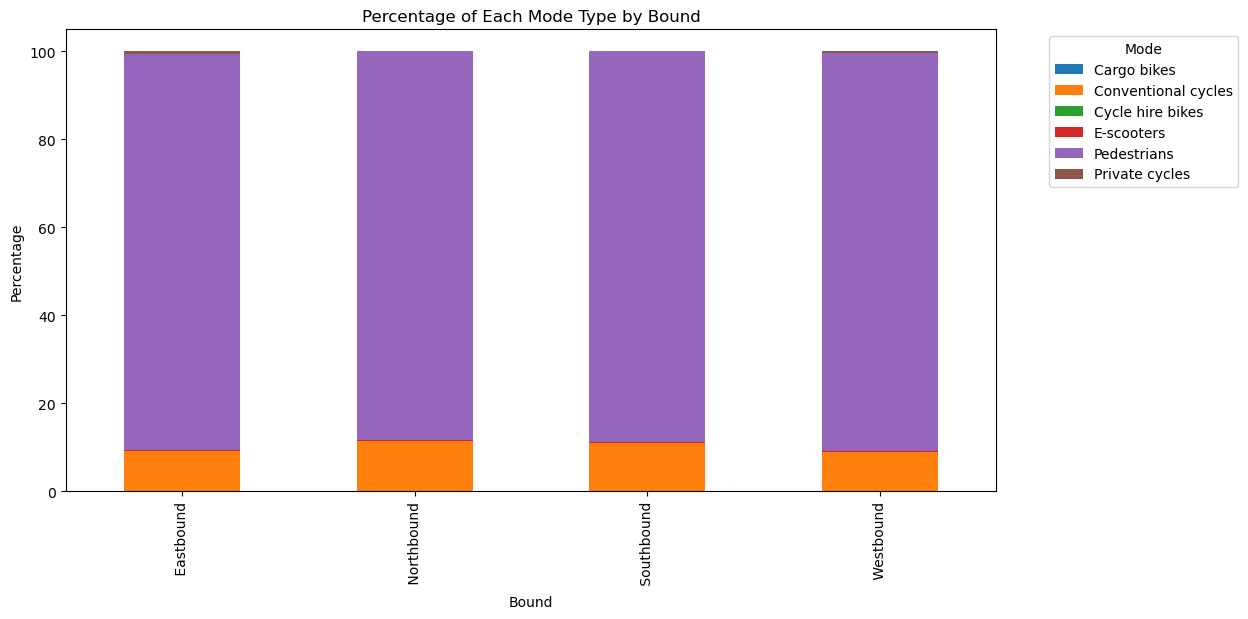

In [97]:
# Pivot the data for better visualization
pivot_data = group_bound.pivot_table(index='Bound', columns='Mode', values='Count', aggfunc='sum')

# Calculate percentage of each mode within each bound
percentage_data = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

# Plot a grouped bar chart
ax = percentage_data.plot(kind='bar', stacked=True, figsize=(12, 6))

# Set labels and title
plt.xlabel("Bound")
plt.ylabel("Percentage")
plt.title("Percentage of Each Mode Type by Bound")
plt.legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


The depicted bar chart imparts valuable insights into the prevalence of each mode type across the four distinct bounds.

A discernible trend emerges when scrutinizing the Eastbound and Westbound directions, where private cycles emerge as the most favored mode, closely trailed by e-scooters. Notably, the inclusion of cycle hire bikes as a significant component underscores the diversity in transportation choices within these bounds.

Conversely, the Northbound and Southbound directions showcase a different landscape, with e-scooters claiming the majority share, followed by cargo bikes. While this information suggests that Northbound and Southbound routes might be favorable for businesses focusing on E-scooters and cargo bikes, it's imperative to acknowledge a data gap. The absence of data on private cycles and cycle hire bikes necessitates caution in drawing definitive conclusions. Further exploration and inclusion of this missing data are essential for a comprehensive assessment of potential business opportunities related to these modes in these particular bounds.

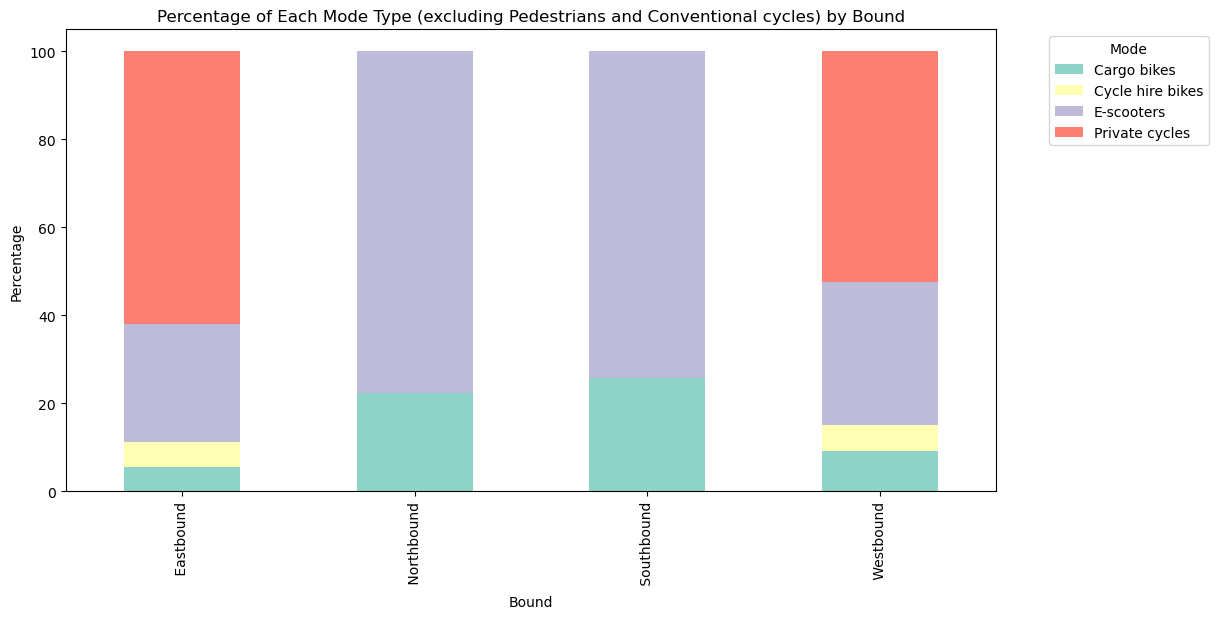

In [98]:
# Pivot the data for better visualization
pivot_data = group_bound.pivot_table(index='Bound', columns='Mode', values='Count', aggfunc='sum')

# Exclude "Pedestrians" and "Conventional cycles" from the plot
modes_to_exclude = ["Pedestrians", "Conventional cycles"]
filtered_data = pivot_data.drop(columns=modes_to_exclude)

# Calculate percentage of each mode within each bound
percentage_data = filtered_data.div(filtered_data.sum(axis=1), axis=0) * 100

# Set up a color palette for better differentiation
colors = sns.color_palette("Set3", n_colors=len(percentage_data.columns))

# Plot a grouped bar chart without "Pedestrians" and "Conventional cycles"
ax = percentage_data.plot(kind='bar', stacked=True, color=colors, figsize=(12, 6))

# Set labels and title
plt.xlabel("Bound")
plt.ylabel("Percentage")
plt.title("Percentage of Each Mode Type (excluding Pedestrians and Conventional cycles) by Bound")
plt.legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


Weather conditions play a pivotal role in influencing mobility patterns. This section explores the impact of weather on pedestrian, cycle, and e-scooter volumes. By understanding how different weather conditions affect user behavior, businesses can adapt their strategies accordingly.

The bar chart below illustrates a comparative analysis of modes of transportation in both dry and wet conditions. Evidently, there is a significant decline in the number of pedestrians and conventional cycles during wet weather.

It is crucial to note, however, that according to statistics provided by Fred Pickhardt (source: https://freetoursbyfoot.com/may-weather-in-london/), London is expected to have only 6-8 rainy days. It is reasonable to anticipate that this trend would persist in June and July, which are considered warmer months compared to May in London.

Furthermore, a noteworthy observation emerges as, once again, the number of pedestrians and conventional cycles far surpasses that of other transportation modes. Subsequently, the upcoming bar chart will specifically focus on all other modes excluding pedestrians and conventional cycles.

Dry Group:


,Count
Mode,
Cargo bikes,4274
Conventional cycles,564541
Cycle hire bikes,1664
E-scooters,13311
Pedestrians,2427795
Private cycles,15262



Wet Group:


,Count
Mode,
Cargo bikes,641
Conventional cycles,48398
E-scooters,980
Pedestrians,226189


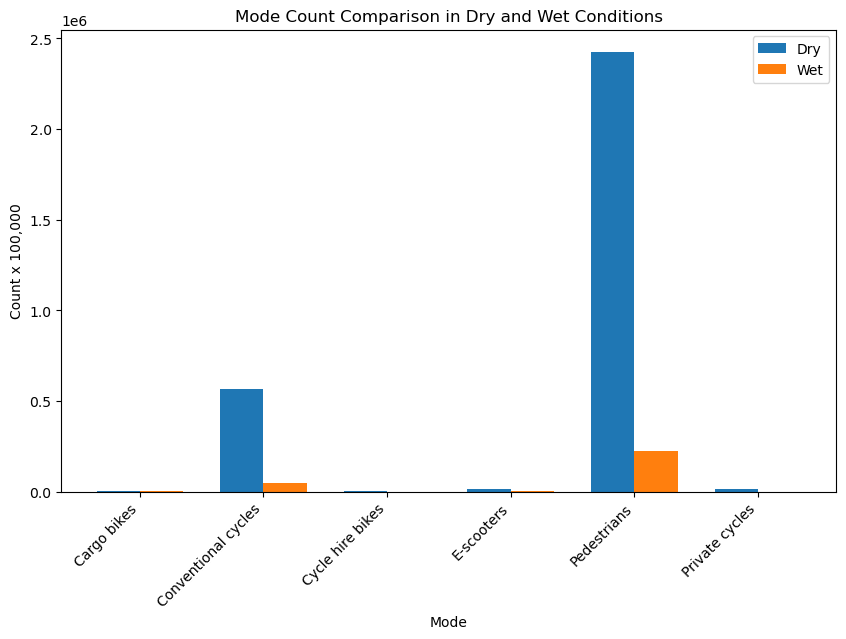

In [100]:
# Group by "Mode" in each DataFrame and aggregate the count
group_dry = df_dry.groupby("Mode").agg({"Count": "sum"})
group_wet = df_wet.groupby("Mode").agg({"Count": "sum"})

print("Dry Group:")
display(group_dry)
print("\nWet Group:")
display(group_wet)

# Ensure the same order of modes for both conditions
all_modes = np.union1d(group_dry.index, group_wet.index)

# Fill missing modes with 0 count
group_dry = group_dry.reindex(all_modes, fill_value=0)
group_wet = group_wet.reindex(all_modes, fill_value=0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
bar_positions = np.arange(len(all_modes))

ax.bar(bar_positions, group_dry["Count"], width=bar_width, label="Dry")
ax.bar(bar_positions + bar_width, group_wet["Count"], width=bar_width, label="Wet")

ax.set_xticks(bar_positions + bar_width / 2)
ax.set_xticklabels(all_modes, rotation=45, ha="right")  # Rotate labels by 45 degrees

ax.set_xlabel("Mode")
ax.set_ylabel("Count x 100,000")
ax.set_title("Mode Count Comparison in Dry and Wet Conditions")
ax.legend()

plt.show()


The presented bar chart offers a comprehensive comparison of mode counts in both dry and wet conditions, specifically excluding conventional cycles and pedestrians.

Upon closer examination, it becomes evident that the counts for all modes experience a noteworthy decrease on wet days, with cycle bike hire registering a complete cessation. This prompts a consideration that closing cycle bike hire services during wet days could be a prudent decision.

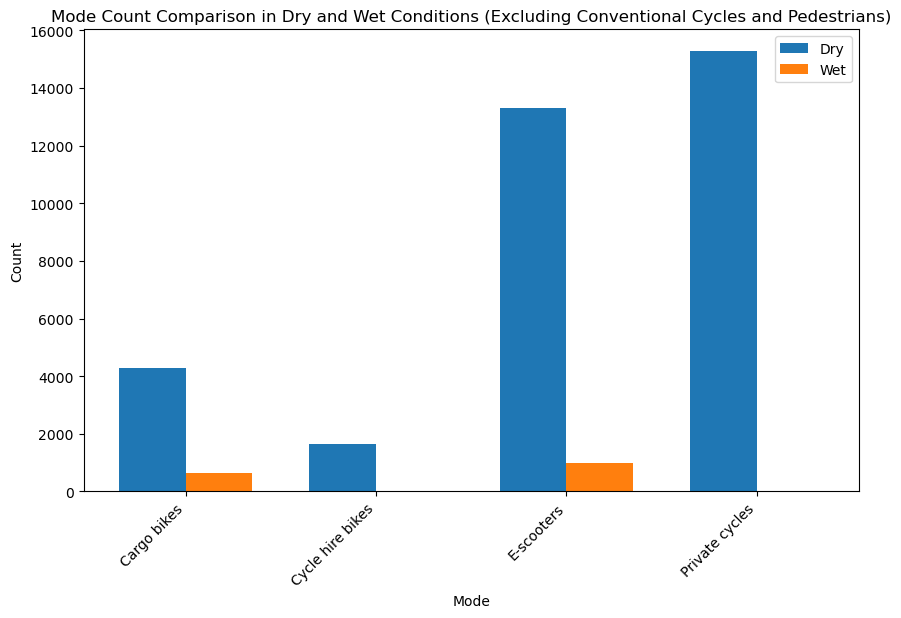

In [101]:
# Exclude "Conventional cycles" and "Pedestrians"
modes_to_exclude = ["Conventional cycles", "Pedestrians"]
df_dry_filtered = df_dry[~df_dry["Mode"].isin(modes_to_exclude)]
df_wet_filtered = df_wet[~df_wet["Mode"].isin(modes_to_exclude)]

# Group by "Mode" in each DataFrame and aggregate the count
group_dry = df_dry_filtered.groupby("Mode").agg({"Count": "sum"})
group_wet = df_wet_filtered.groupby("Mode").agg({"Count": "sum"})

# Ensure the same order of modes for both conditions
all_modes = np.union1d(group_dry.index, group_wet.index)

# Fill missing modes with 0 count
group_dry = group_dry.reindex(all_modes, fill_value=0)
group_wet = group_wet.reindex(all_modes, fill_value=0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
bar_positions = np.arange(len(all_modes))

ax.bar(bar_positions, group_dry["Count"], width=bar_width, label="Dry")
ax.bar(bar_positions + bar_width, group_wet["Count"], width=bar_width, label="Wet")

ax.set_xticks(bar_positions + bar_width / 2)
ax.set_xticklabels(all_modes, rotation=45, ha="right")  # Rotate labels by 45 degrees

ax.set_xlabel("Mode")
ax.set_ylabel("Count")
ax.set_title("Mode Count Comparison in Dry and Wet Conditions (Excluding Conventional Cycles and Pedestrians)")
ax.legend()

plt.show()


The three graphs below illustrate the cumulative count of all modes for each day in the database:

The highest point in May 2022 occurred on May 17th.
June 14th marked the peak in total counts for the month of June 2022.
The summit in July 2022 was reached on July 7th.

These visualizations provide a clear overview of the daily trends, emphasizing significant peaks on specific dates in each respective month

Understanding monthly patterns is vital for long-term planning and strategy development. By visualizing monthly trends, stakeholders can identify seasonality and plan promotional activities during peak months.

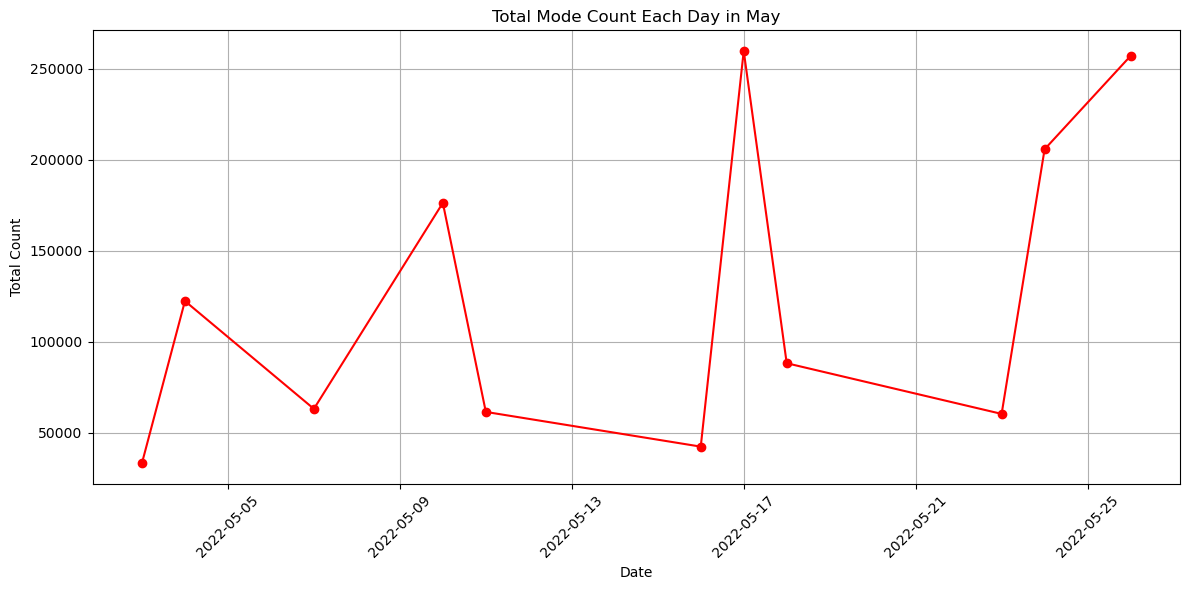

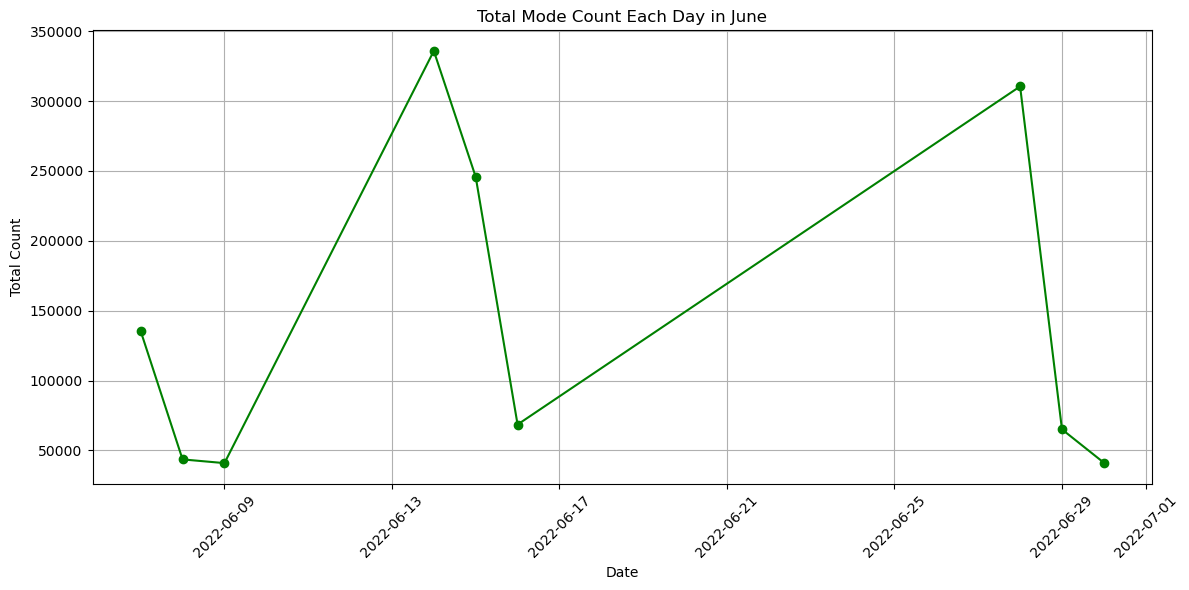

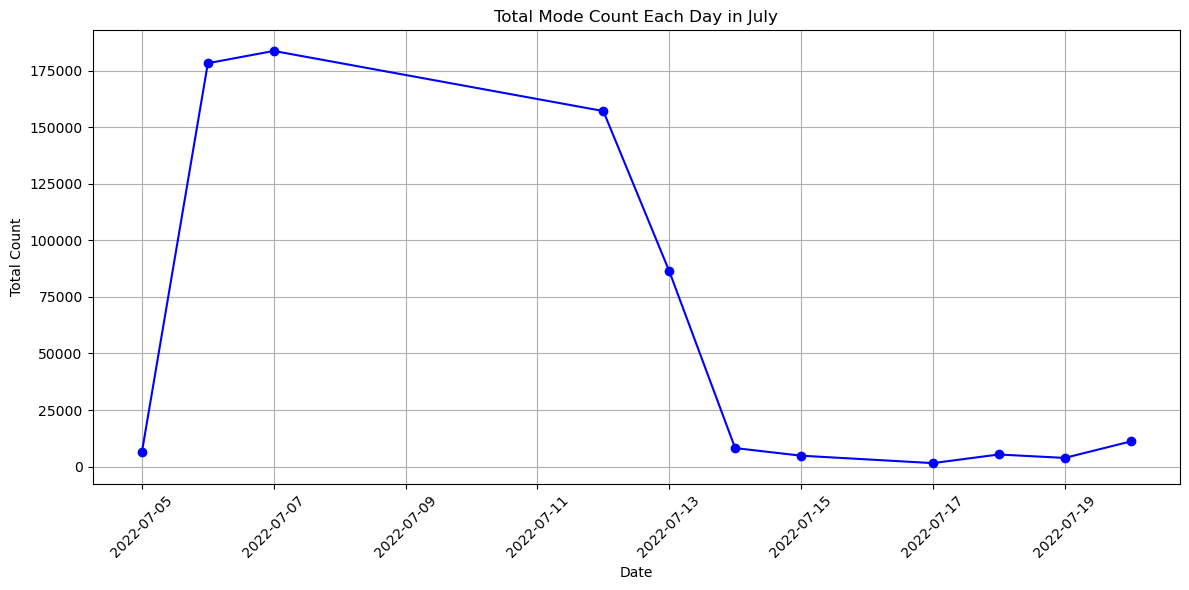

In [102]:
# Function to plot total mode count for a specific month
def plot_monthly_data(data, month_name, color):
    total_count_per_day = data.groupby("Date")["Count"].sum()

    plt.figure(figsize=(12, 6))
    plt.plot(total_count_per_day.index, total_count_per_day.values, marker='o', linestyle='-', color=color)
    plt.title(f'Total Mode Count Each Day in {month_name}')
    plt.xlabel('Date')
    plt.ylabel('Total Count')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

# Plot for May
plot_monthly_data(cleaned_data[cleaned_data["Month"] == "May"], "May", 'r')
plt.show()

# Plot for June
plot_monthly_data(cleaned_data[cleaned_data["Month"] == "June"], "June", 'g')
plt.show()

# Plot for July
plot_monthly_data(cleaned_data[cleaned_data["Month"] == "July"], "July", 'b')
plt.show()


# Conclusion

In conclusion, this extended analysis has provided a comprehensive exploration of temporal trends and weather impact on pedestrian, cycle, and e-scooter volumes in Central London. Stakeholders in the transportation sector can leverage these insights for strategic decision-making.

Recommendations for businesses and governmental organizations:

Optimize Daily Operations:
- Identify peak times for each mode based on daily trends.
- Adjust staffing levels and service availability to align with daily demand patterns.

Strategic Planning for Monthly Variation:
- Plan marketing and promotional activities considering monthly variations.
- Anticipate and prepare for seasonal changes in user behavior.

Weather-Adaptive Strategies:
- Develop weather-specific strategies to address fluctuations in demand.
- Offer promotions or incentives during adverse weather conditions to encourage usage.

By incorporating these recommendations, businesses and governmental organizations can enhance their services, improve user experience, and contribute to a more efficient and sustainable transportation ecosystem in Central London.